In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.font_manager import fontManager, FontProperties


try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

df_path = "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/Datasets/new_data.csv"
df = pd.read_csv(df_path)

PALETTE = ["#5e17eb", "#ff6b6b", "#00c49a"]
FONT_CANDIDATES = [
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_ITMO_2026/HSE_FONTS_FOR_GRAPHS_copy/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/DANO_NES_2026/HSE_FONTS_FOR_GRAPHS/HSESlab-Regular.ttf",
    "/Users/royalmustaches/Documents/Programming/Dano/Practice/Organization/Fonts_for_projects/HSESlab-Regular.ttf",
]

FONT_NAME = "DejaVu Sans"
for font_path in FONT_CANDIDATES:
    if os.path.exists(font_path):
        fontManager.addfont(font_path)
        FONT_NAME = FontProperties(fname=font_path).get_name()
        break

sns.set_theme(style="whitegrid", font=FONT_NAME, context="notebook", palette=PALETTE)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.linestyle"] = "--"

PRIMARY = "#5e17eb"
SECONDARY = "#ff6b6b"
ACCENT = "#00c49a"

In [6]:
import pandas as pd
import statsmodels.formula.api as smf

# =========================
# 1. Подготовка данных
# =========================

df_model = df.copy()

df_model.columns = (
    df_model.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

# Оставляем нужные переменные
lifestyle_col = 'lifestyle_super_cnt' if 'lifestyle_super_cnt' in df_model.columns else 'lifestyle___super_cnt'
df_model = df_model[
    [lifestyle_col, 'cb_percent', 'markup']
].copy()
df_model = df_model.rename(columns={lifestyle_col: 'lifestyle_super_cnt'})

# Приводим к числовому формату
df_model['lifestyle_super_cnt'] = pd.to_numeric(df_model['lifestyle_super_cnt'], errors='coerce')
df_model['cb_percent'] = pd.to_numeric(df_model['cb_percent'], errors='coerce')
df_model['markup'] = pd.to_numeric(df_model['markup'], errors='coerce')

# Удаляем пропуски
df_model = df_model.dropna().copy()

# Оставляем только нужные уровни наценки
df_model = df_model[df_model['markup'].isin([0, 1, 5, 9])].copy()

# =========================
# 2. Регрессия без категориальных переменных
# =========================

formula = """
lifestyle_super_cnt ~
    cb_percent
"""

model = smf.ols(formula=formula, data=df_model).fit(cov_type='HC3')

print(model.summary())


                             OLS Regression Results                            
Dep. Variable:     lifestyle_super_cnt   R-squared:                       0.045
Model:                             OLS   Adj. R-squared:                  0.045
Method:                  Least Squares   F-statistic:                     4180.
Date:                 Sat, 25 Apr 2026   Prob (F-statistic):               0.00
Time:                         17:12:43   Log-Likelihood:            -5.7666e+05
No. Observations:                95729   AIC:                         1.153e+06
Df Residuals:                    95727   BIC:                         1.153e+06
Df Model:                            1                                         
Covariance Type:                   HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    114.5093      0.680    168.33

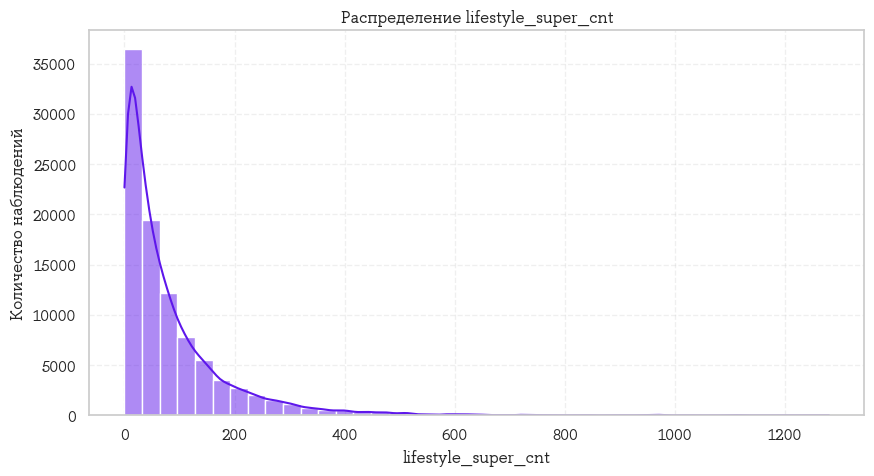

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Подготовка
df_plot = df.copy()
df_plot.columns = df_plot.columns.str.replace('\ufeff', '', regex=False).str.strip()

# Переводим в число и убираем пропуски
x = pd.to_numeric(df_plot['lifestyle___super_cnt'], errors='coerce').dropna()

# График распределения
plt.figure(figsize=(10, 5))

sns.histplot(
    x,
    bins=40,
    kde=True
)

plt.title('Распределение lifestyle_super_cnt')
plt.xlabel('lifestyle_super_cnt')
plt.ylabel('Количество наблюдений')

plt.show()

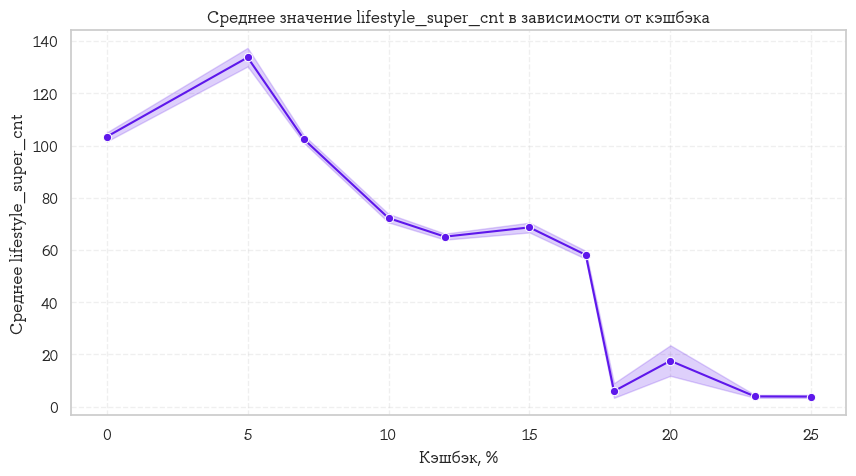

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Подготовка данных
# =========================

df_plot = df.copy()

df_plot.columns = (
    df_plot.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

df_plot['lifestyle_super_cnt'] = pd.to_numeric(
    df_plot['lifestyle___super_cnt'],
    errors='coerce'
)

df_plot['cb_percent'] = pd.to_numeric(
    df_plot['cb_percent'],
    errors='coerce'
)

df_plot = df_plot.dropna(
    subset=['lifestyle___super_cnt', 'cb_percent']
).copy()

# =========================
# 2. График зависимости от кэшбэка
# =========================

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_plot,
    x='cb_percent',
    y='lifestyle___super_cnt',
    estimator='mean',
    errorbar=('ci', 95),
    marker='o'
)

plt.title('Среднее значение lifestyle_super_cnt в зависимости от кэшбэка')
plt.xlabel('Кэшбэк, %')
plt.ylabel('Среднее lifestyle_super_cnt')

plt.grid(alpha=0.3)
plt.show()

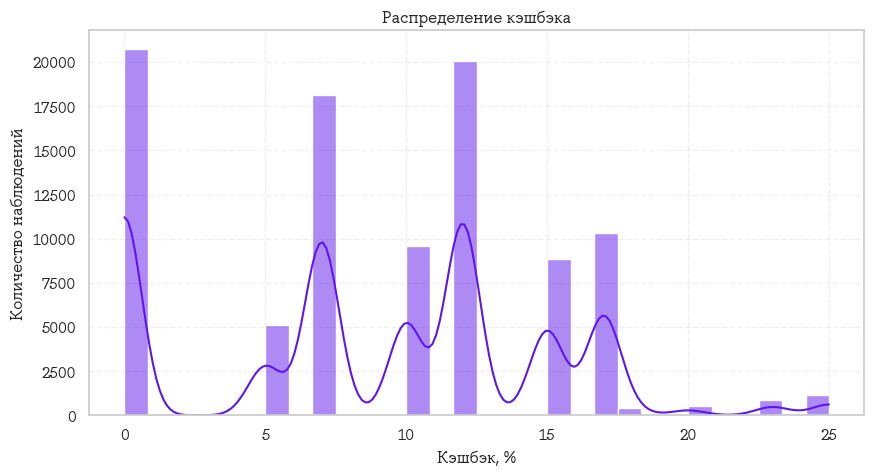

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Подготовка данных
# =========================

df_plot = df.copy()

df_plot.columns = (
    df_plot.columns
    .str.replace('\ufeff', '', regex=False)
    .str.strip()
)

df_plot['cb_percent'] = pd.to_numeric(
    df_plot['cb_percent'],
    errors='coerce'
)

x = df_plot['cb_percent'].dropna()

# =========================
# 2. График распределения кэшбэка
# =========================

plt.figure(figsize=(10, 5))

sns.histplot(
    x,
    bins=30,
    kde=True
)

plt.title('Распределение кэшбэка')
plt.xlabel('Кэшбэк, %')
plt.ylabel('Количество наблюдений')

plt.grid(alpha=0.3)
plt.show()